# 03 — Data Visualization
Distributions, correlations, protocol analysis — KDD Cup 1999

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CLEAN_PATH = r"C:\Users\THINKBOOK\Network-intrusion-EDA\data\processed\kdd_clean.csv"
df = pd.read_csv(CLEAN_PATH)
print(f"Shape: {df.shape}")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

Shape: (494021, 42)


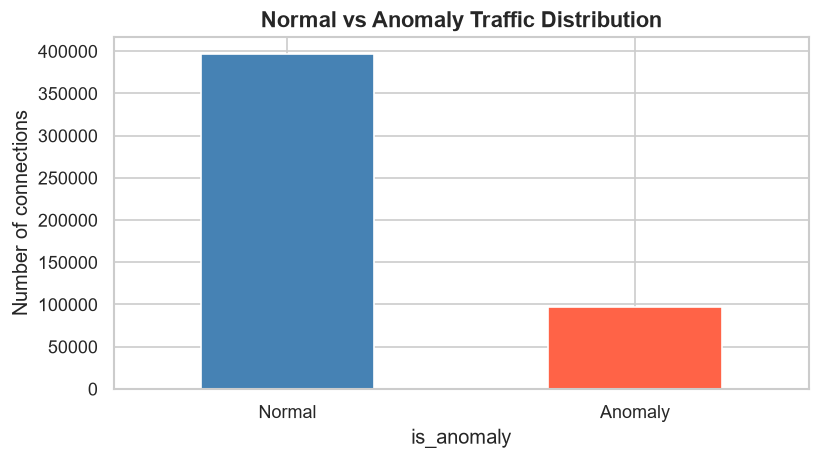

In [2]:
# Figure 1 — Normal vs Anomaly distribution
fig, ax = plt.subplots(figsize=(7, 4))
df['is_anomaly'].value_counts().plot(
    kind='bar', ax=ax,
    color=['steelblue', 'tomato'],
    edgecolor='white'
)
ax.set_xticklabels(['Normal', 'Anomaly'], rotation=0)
ax.set_title('Normal vs Anomaly Traffic Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of connections')
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig1_distribution.png")
plt.show()

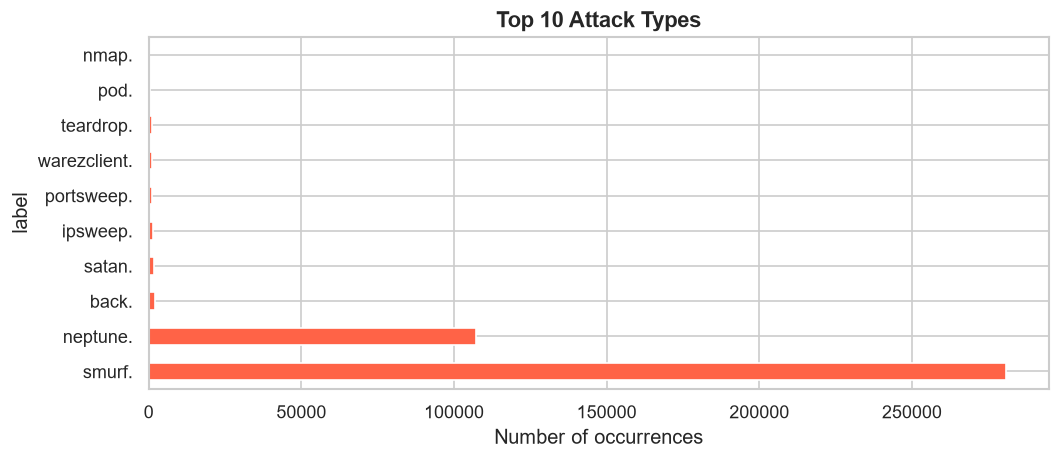

In [3]:
# Figure 2 — Top 10 attack types
attack_counts = df[df['is_anomaly'] == 1]['label'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4))
attack_counts.plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Top 10 Attack Types', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of occurrences')
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig2_attack_types.png")
plt.show()

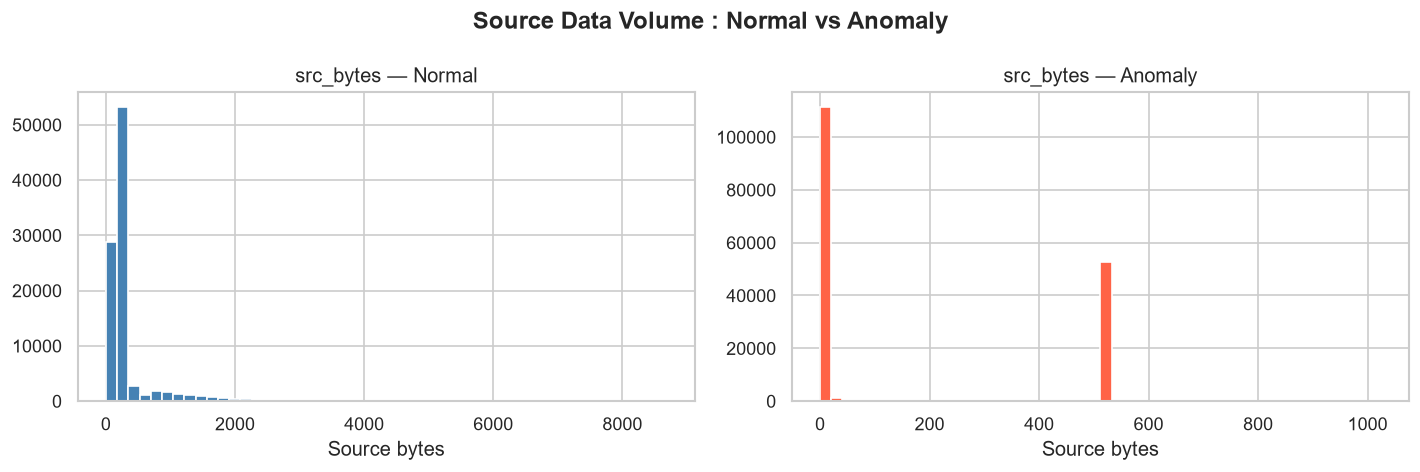

In [4]:
# Figure 3 — src_bytes distribution Normal vs Anomaly
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, color in zip(axes, [0, 1], ['steelblue', 'tomato']):
    subset = df[df['is_anomaly'] == label]['src_bytes']
    subset[subset < subset.quantile(0.99)].hist(bins=50, ax=ax, color=color)
    ax.set_title(f"src_bytes — {'Normal' if label == 0 else 'Anomaly'}")
    ax.set_xlabel('Source bytes')
plt.suptitle('Source Data Volume : Normal vs Anomaly', fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig3_src_bytes.png")
plt.show()

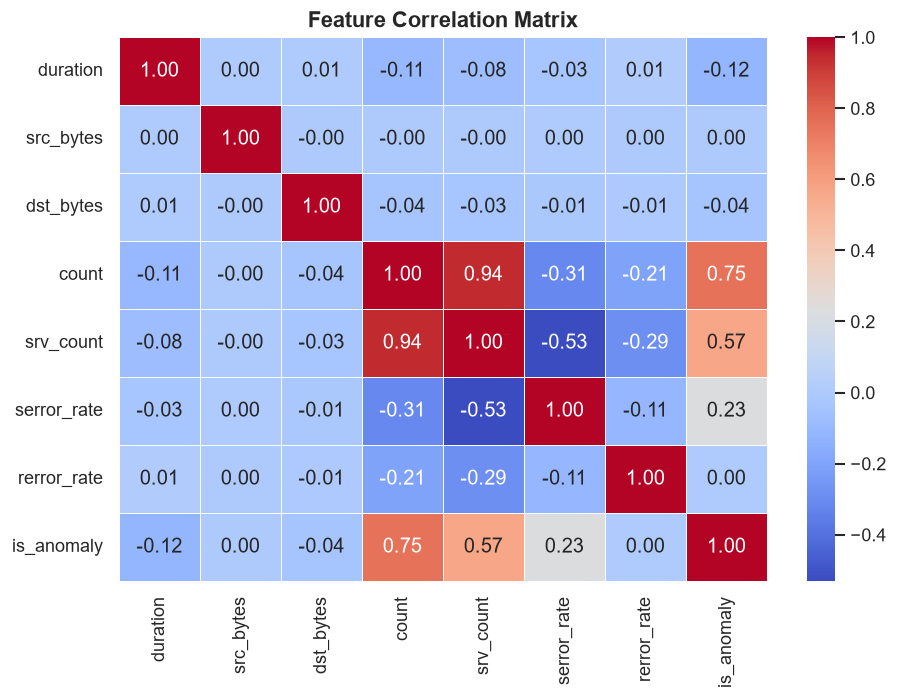

In [5]:
# Figure 4 — Correlation heatmap
top_features = ['duration', 'src_bytes', 'dst_bytes', 'count',
                'srv_count', 'serror_rate', 'rerror_rate', 'is_anomaly']
corr = df[top_features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig4_correlation.png")
plt.show()

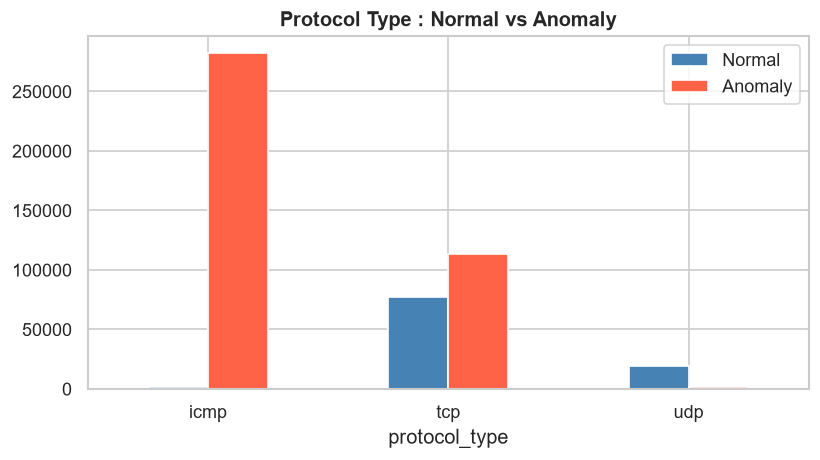

In [6]:
# Figure 5 — Protocol type vs traffic
proto_anomaly = df.groupby(['protocol_type', 'is_anomaly']).size().unstack()
proto_anomaly.plot(kind='bar', figsize=(7, 4),
                   color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Protocol Type : Normal vs Anomaly', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(['Normal', 'Anomaly'])
plt.tight_layout()
plt.savefig(r"C:\Users\THINKBOOK\Network-intrusion-EDA\outputs\figures\fig5_protocols.png")
plt.show()

## Observations
- ~80% of traffic is anomalous — heavily imbalanced dataset
- DoS attacks dominate : smurf and neptune are the most frequent
- TCP protocol is strongly associated with attack traffic
- src_bytes and serror_rate are the most discriminative features
- Strong negative correlation between same_srv_rate and serror_rate